In [51]:
library(ggplot2)
library(vroom)
library(LSD)
library(ggplotify)
library(patchwork)
library(dplyr)
source("utils.R")

In [51]:
mapped = read.table("../data/mapped.tsv",header = T)
mapped_rate.p = stats_mapping_rate(mapped)

In [37]:
suppressMessages(
{Y1.stat = vroom("../data/Y1.stat.tsv",num_threads = 20)
Y2.stat = vroom("../data/Y2.stat.tsv",num_threads = 20)
Y3.stat = vroom("../data/Y3.stat.tsv",num_threads = 20)}
)
suppressMessages(
{Y1.stat.tx = vroom("../data/Y1.stat.transcriptome.tsv",num_threads = 20)
Y2.stat.tx = vroom("../data/Y2.stat.transcriptome.tsv",num_threads = 20)
Y3.stat.tx = vroom("../data/Y3.stat.transcriptome.tsv",num_threads = 20)}
)

In [33]:
Y1.stat.p = as.ggplot(~heatscatter(Y1.stat$readLength,Y1.stat$alignedLength,log = "xy",
xlab = "Read length",ylab = "Aligned length",main = "Y1 genome"))
Y2.stat.p = as.ggplot(~heatscatter(Y2.stat$readLength,Y2.stat$alignedLength,log = "xy",
xlab = "Read length",ylab = "Aligned length",main = "Y2 genome"))
Y3.stat.p = as.ggplot(~heatscatter(Y3.stat$readLength,Y3.stat$alignedLength,log = "xy",
xlab = "Read length",ylab = "Aligned length",main = "Y3 genome"))

In [38]:
Y1.stat.tx.p = as.ggplot(~heatscatter(Y1.stat.tx$readLength,Y1.stat.tx$alignedLength,log = "xy",
xlab = "Read length",ylab = "Aligned length",main = "Y1 transcriptome"))
Y2.stat.tx.p = as.ggplot(~heatscatter(Y2.stat.tx$readLength,Y2.stat.tx$alignedLength,log = "xy",
xlab = "Read length",ylab = "Aligned length",main = "Y2 transcriptome"))
Y3.stat.tx.p = as.ggplot(~heatscatter(Y3.stat.tx$readLength,Y3.stat.tx$alignedLength,log = "xy",
xlab = "Read length",ylab = "Aligned length",main = "Y3 transcriptome"))

In [85]:
options(repr.plot.width=30, repr.plot.height=20)
Y.alignlen.p = (Y1.stat.p|Y2.stat.p|Y3.stat.p)/(Y1.stat.tx.p|Y2.stat.tx.p|Y3.stat.tx.p)

### Junction number statistics

In [186]:
suppressMessages({Y1.junction = vroom("../data/Y1.junction.groupbygene.tsv")
Y2.junction = vroom("../data/Y2.junction.groupbygene.tsv")
Y3.junction = vroom("../data/Y3.junction.groupbygene.tsv")})

In [194]:
Y1.junction$type[is.na(Y1.junction$type)] = "inter-gene"
Y1.junction$sample = "Y1"
Y2.junction$type[is.na(Y2.junction$type)] = "inter-gene"
Y2.junction$sample = "Y2"
Y3.junction$type[is.na(Y3.junction$type)] = "inter-gene"
Y3.junction$sample = "Y3"
Y1.junction$type[which(Y1.junction$type == "annotated")] = "intra-gene"
Y2.junction$type[which(Y2.junction$type == "annotated")] = "intra-gene"
Y3.junction$type[which(Y3.junction$type == "annotated")] = "intra-gene"
Y.junction = bind_rows(Y1.junction,Y2.junction,Y3.junction)

Warning message:
“One or more parsing issues, call `problems()` on your data frame for details,
e.g.:
  dat <- vroom(...)
  problems(dat)”


In [303]:
Y1.n_junction.p = Y1.junction %>% unique() %>% filter(!is.na(n_junction)) %>% group_by(type,n_junction) %>% 
summarise(count = n()) %>% pull(n_junction)

`summarise()` has grouped output by 'type'. You can override using the
`.groups` argument.


In [324]:
Y1.n_junction.p = Y1.junction %>% unique() %>% filter(!is.na(n_junction)) %>% group_by(type,n_junction) %>% 
summarise(count = n())  %>% ggplot(aes(x = n_junction,y = count,fill = type)) + 
geom_bar(stat="identity",position = position_dodge2(preserve = "single")) + theme_bw() + 
scale_y_continuous(trans = "log1p",breaks = 4^(1:13)) + ggtitle("Y1 Junction number statistics") + 
scale_fill_manual(values = c("#00DFA2","#FF0060")) + scale_color_manual(values = c("#00DFA2","#FF0060"))

Y2.n_junction.p = Y2.junction %>% unique() %>% filter(!is.na(n_junction)) %>% group_by(type,n_junction) %>% 
summarise(count = n()) %>% ggplot(aes(x = n_junction,y = count,fill = type)) + 
geom_bar(stat="identity",position = position_dodge2(preserve = "single")) + theme_bw() + 
scale_y_continuous(trans = "log1p",breaks = 4^(1:13)) + ggtitle("Y2 Junction number statistics")+
scale_fill_manual(values = c("#00DFA2","#FF0060")) + scale_color_manual(values = c("#00DFA2","#FF0060"))

Y3.n_junction.p = Y3.junction %>% unique() %>% filter(!is.na(n_junction)) %>% group_by(type,n_junction) %>% 
summarise(count = n()) %>% ggplot(aes(x = n_junction,y = count,fill = type)) + 
geom_bar(stat="identity",position = position_dodge2(preserve = "single")) + theme_bw() + 
scale_y_continuous(trans = "log1p",breaks = 4^(1:13)) + ggtitle("Y3 Junction number statistics")+
scale_fill_manual(values = c("#00DFA2","#FF0060")) + scale_color_manual(values = c("#00DFA2","#FF0060"))

`summarise()` has grouped output by 'type'. You can override using the
`.groups` argument.
`summarise()` has grouped output by 'type'. You can override using the
`.groups` argument.
`summarise()` has grouped output by 'type'. You can override using the
`.groups` argument.


In [325]:
options(repr.plot.width=18, repr.plot.height=5)
Y.njunction.p = Y1.n_junction.p|Y2.n_junction.p|Y3.n_junction.p

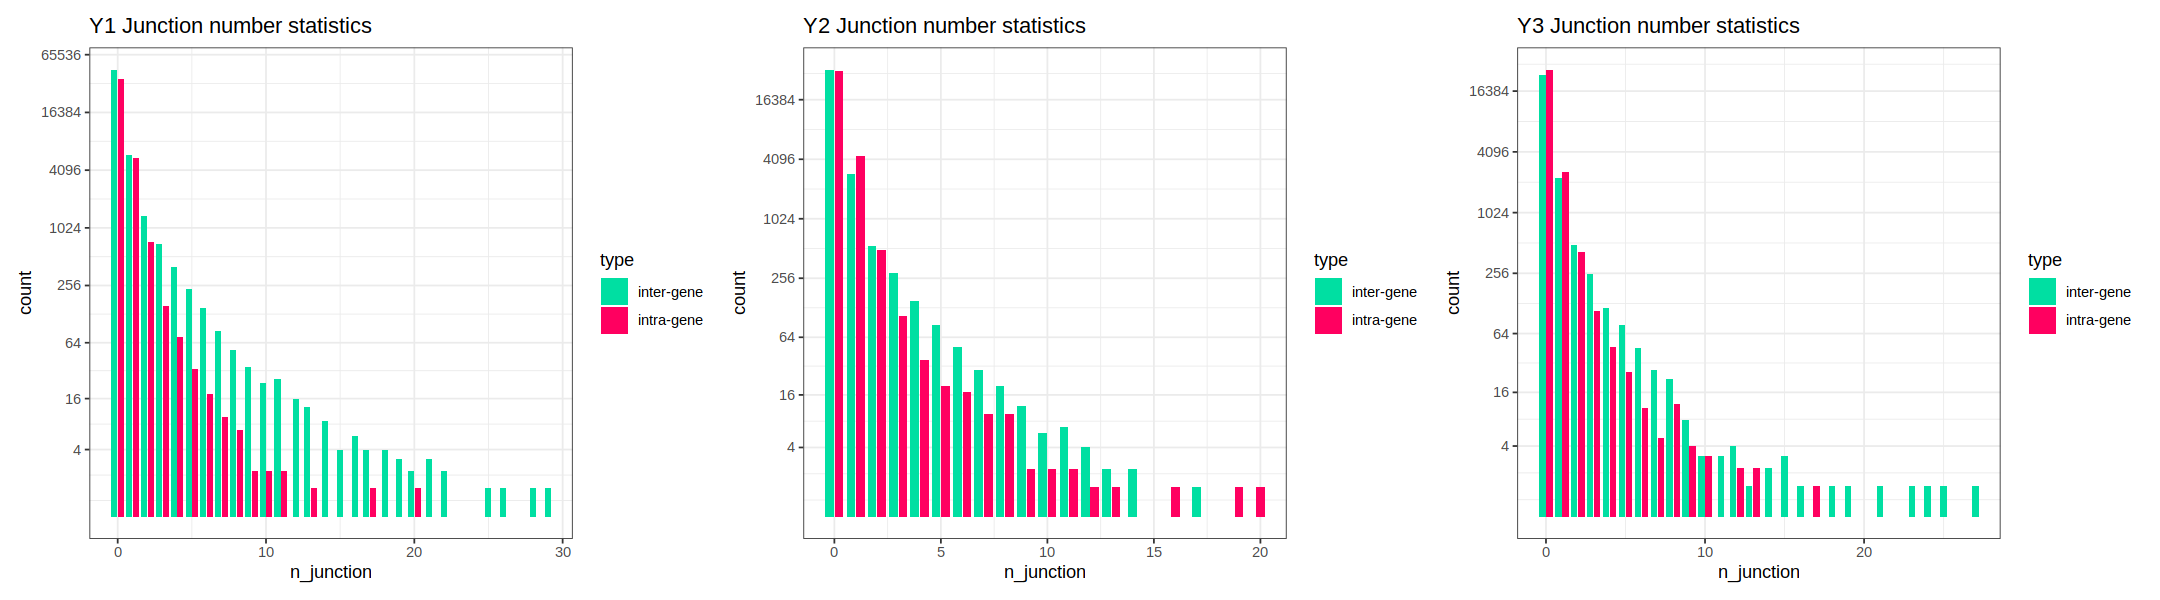

In [326]:
Y.njunction.p

### Junction width statistics

In [327]:
suppressMessages({Y1.junction.width = vroom("../data/Y1.junctionwidth.groupbygene.tsv")
Y2.junction.width = vroom("../data/Y2.junctionwidth.groupbygene.tsv")
Y3.junction.width = vroom("../data/Y3.junctionwidth.groupbygene.tsv")})

In [328]:
Y1.junction.width$type[is.na(Y1.junction.width$type)] = "inter-gene"
Y1.junction.width$sample = "Y1"
Y2.junction.width$type[is.na(Y2.junction.width$type)] = "inter-gene"
Y2.junction.width$sample = "Y2"
Y3.junction.width$type[is.na(Y3.junction.width$type)] = "inter-gene"
Y3.junction.width$sample = "Y3"
Y1.junction.width$type[which(Y1.junction.width$type == "annotated")] = "intra-gene"
Y2.junction.width$type[which(Y2.junction.width$type == "annotated")] = "intra-gene"
Y3.junction.width$type[which(Y3.junction.width$type == "annotated")] = "intra-gene"
Y.junction.width = bind_rows(Y1.junction.width,Y2.junction.width,Y3.junction.width)

In [356]:
dodge <- position_dodge(width = 0.8)
junction.width.p = Y.junction.width %>% unique() %>% ggplot(aes(x = factor(sample),y = junction_width,fill = factor(type)))+
geom_violin(position=dodge,linewidth=1)+geom_boxplot(position=dodge,width=0.1,outlier.shape = NA,linewidth=1)+ 
theme_bw() + 
scale_y_continuous(trans = "log1p",breaks = 4^(1:13)) + ggtitle("Junction width")+
scale_fill_manual(values = c("#00DFA2","#FF0060"))

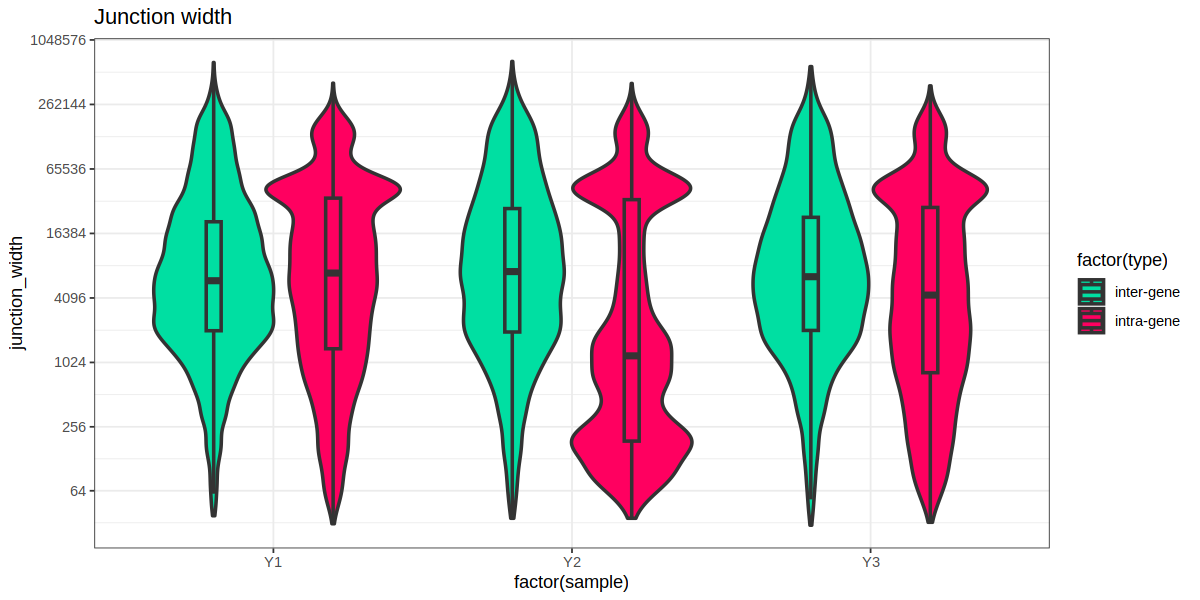

In [357]:
options(repr.plot.width=10, repr.plot.height=5)
junction.width.p

### Exon width statistics

In [217]:
suppressMessages({Y1.exon.width = vroom("../data/Y1.exonwidth.groupbygene.tsv")
Y2.exon.width = vroom("../data/Y2.exonwidth.groupbygene.tsv")
Y3.exon.width = vroom("../data/Y3.exonwidth.groupbygene.tsv")})

In [218]:
Y1.exon.width$type[is.na(Y1.exon.width$type)] = "inter-gene"
Y1.exon.width$sample = "Y1"
Y2.exon.width$type[is.na(Y2.exon.width$type)] = "inter-gene"
Y2.exon.width$sample = "Y2"
Y3.exon.width$type[is.na(Y3.exon.width$type)] = "inter-gene"
Y3.exon.width$sample = "Y3"
Y1.exon.width$type[which(Y1.exon.width$type == "annotated")] = "intra-gene"
Y2.exon.width$type[which(Y2.exon.width$type == "annotated")] = "intra-gene"
Y3.exon.width$type[which(Y3.exon.width$type == "annotated")] = "intra-gene"
Y.exon.width = bind_rows(Y1.exon.width,Y2.exon.width,Y3.exon.width)

In [358]:
exon.width.p = Y.exon.width %>% unique() %>% ggplot(aes(x = factor(sample),y = junction_width,fill = factor(type)))+
geom_violin(position=dodge,linewidth=1)+geom_boxplot(position=dodge,width=0.1,outlier.shape = NA,linewidth=1)+ 
theme_bw() + 
scale_y_continuous(trans = "log1p",breaks = 4^(1:13)) + ggtitle("Junction width")+
scale_fill_manual(values = c("#00DFA2","#FF0060"))

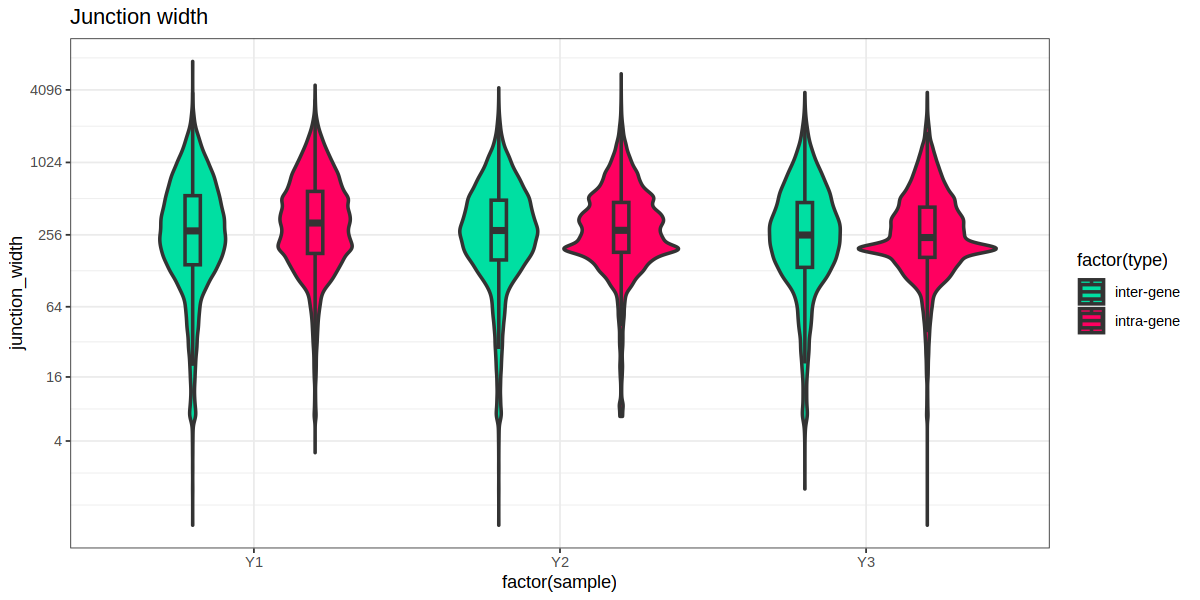

In [359]:
exon.width.p

### Base level accuracy

In [221]:
suppressMessages({Y1.baseaccuracy = vroom("../data/Y1.baseaccuracy.tsv")
Y2.baseaccuracy = vroom("../data/Y2.baseaccuracy.tsv")
Y3.baseaccuracy = vroom("../data/Y3.baseaccuracy.tsv")})

In [222]:
Y1.baseaccuracy$type[is.na(Y1.baseaccuracy$type)] = "inter-gene"
Y1.baseaccuracy$sample = "Y1"
Y2.baseaccuracy$type[is.na(Y2.baseaccuracy$type)] = "inter-gene"
Y2.baseaccuracy$sample = "Y2"
Y3.baseaccuracy$type[is.na(Y3.baseaccuracy$type)] = "inter-gene"
Y3.baseaccuracy$sample = "Y3"
Y1.baseaccuracy$type[which(Y1.baseaccuracy$type == "annotated")] = "intra-gene"
Y2.baseaccuracy$type[which(Y2.baseaccuracy$type == "annotated")] = "intra-gene"
Y3.baseaccuracy$type[which(Y3.baseaccuracy$type == "annotated")] = "intra-gene"
Y.baseaccuracy = bind_rows(Y1.baseaccuracy,Y2.baseaccuracy,Y3.baseaccuracy)

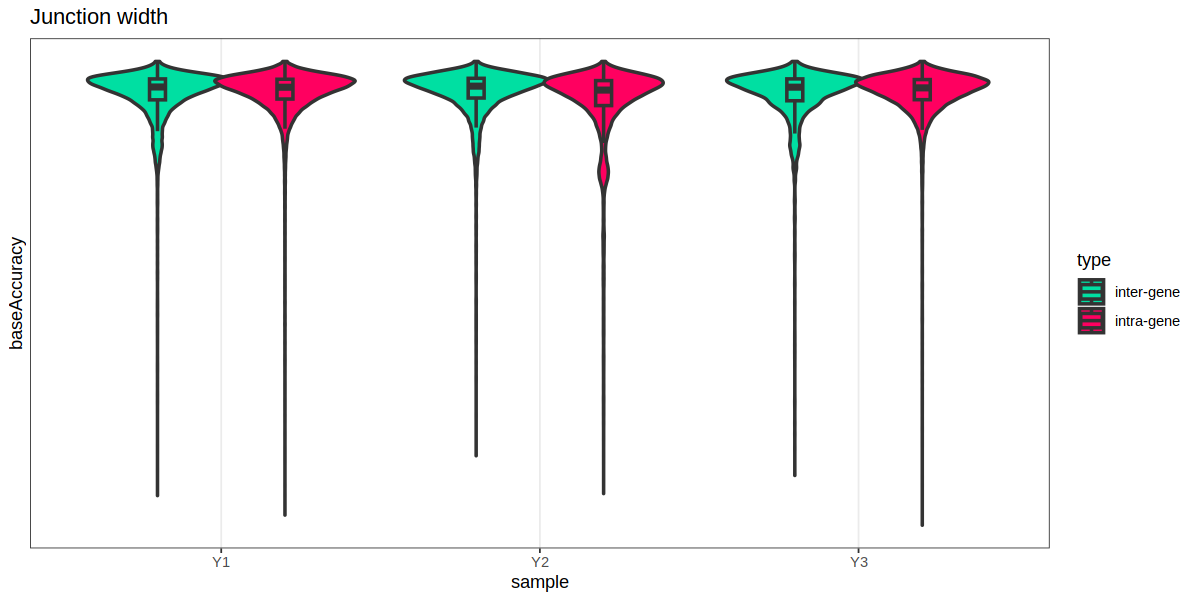

In [360]:
Y.baseaccuracy %>% unique()  %>% ggplot(aes(x = sample,y = baseAccuracy,fill = type))+
geom_violin(position=dodge,linewidth=1)+geom_boxplot(position=dodge,width=0.1,outlier.shape = NA,linewidth=1)+ 
theme_bw() + 
scale_y_continuous(trans = "log1p",breaks = 4^(1:13)) + ggtitle("Junction width")+
scale_fill_manual(values = c("#00DFA2","#FF0060"))

### Transcript unit

In [230]:
suppressMessages({Y1.tu = vroom("../data/Y1.cluster.tsv")
Y2.tu = vroom("../data/Y2.cluster.tsv")
Y3.tu = vroom("../data/Y3.cluster.tsv")})

In [231]:
Y1.tu$type[is.na(Y1.tu$type)] = "inter-gene"
Y1.tu$sample = "Y1"
Y2.tu$type[is.na(Y2.tu$type)] = "inter-gene"
Y2.tu$sample = "Y2"
Y3.tu$type[is.na(Y3.tu$type)] = "inter-gene"
Y3.tu$sample = "Y3"
Y1.tu$type[which(Y1.tu$type == "annotated")] = "intra-gene"
Y2.tu$type[which(Y2.tu$type == "annotated")] = "intra-gene"
Y3.tu$type[which(Y3.tu$type == "annotated")] = "intra-gene"
Y.tu = bind_rows(Y1.tu,Y2.tu,Y3.tu)

In [363]:
options(repr.plot.width=5, repr.plot.height=5)
Y.tu.p = Y.tu %>% unique()  %>% ggplot(aes(x = cluster_size,color = type))+
geom_density(linewidth = 1) + theme_classic()+scale_x_continuous(trans = "log1p",breaks = 4^(1:8)) + 
ggtitle("Cluster size")+
scale_color_manual(values = c("#00DFA2","#FF0060"))

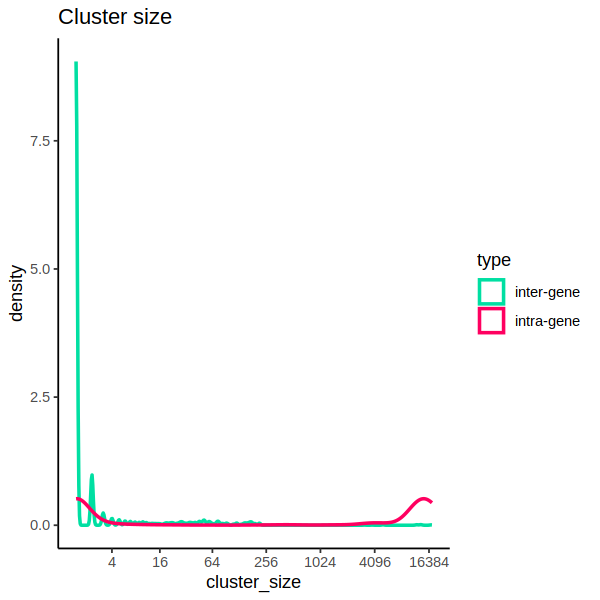

In [364]:
Y.tu.p

### aligned length by gene

In [365]:
suppressMessages({Y1.algnedbygene = vroom("../data/Y1.alignedlengthbygene.tsv")
Y2.algnedbygene = vroom("../data/Y2.alignedlengthbygene.tsv")
Y3.algnedbygene = vroom("../data/Y3.alignedlengthbygene.tsv")})

In [366]:
Y1.algnedbygene$type[is.na(Y1.algnedbygene$type)] = "inter-gene"
Y1.algnedbygene$sample = "Y1"
Y2.algnedbygene$type[is.na(Y2.algnedbygene$type)] = "inter-gene"
Y2.algnedbygene$sample = "Y2"
Y3.algnedbygene$type[is.na(Y3.algnedbygene$type)] = "inter-gene"
Y3.algnedbygene$sample = "Y3"
Y1.algnedbygene$type[which(Y1.algnedbygene$type == "annotated")] = "intra-gene"
Y2.algnedbygene$type[which(Y2.algnedbygene$type == "annotated")] = "intra-gene"
Y3.algnedbygene$type[which(Y3.algnedbygene$type == "annotated")] = "intra-gene"
Y.algnedbygene = bind_rows(Y1.algnedbygene,Y2.algnedbygene,Y3.algnedbygene)

In [367]:
options(repr.plot.width=5, repr.plot.height=5)
Y.algnedbygene.p = Y.algnedbygene %>% unique()  %>% ggplot(aes(x = alignedLength,color = type))+
geom_density(alpha=0.5,size = 1) + theme_classic()+scale_x_continuous(trans = "log1p",breaks = 4^(1:8)) + 
ggtitle("Cluster size") + scale_color_manual(values = c("#00DFA2","#FF0060"))

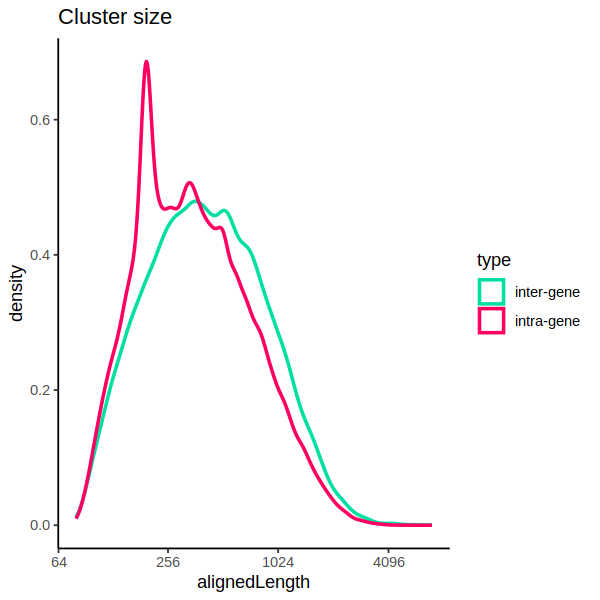

In [368]:
Y.algnedbygene.p